Upload Advertising.csv


Saving Advertising.csv to Advertising (1).csv

First 5 Rows:
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Missing Values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

Statistical Summary:
       Unnamed: 0          TV       Radio   Newspaper       Sal

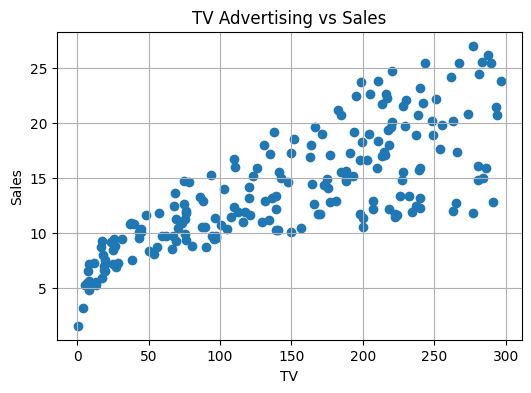

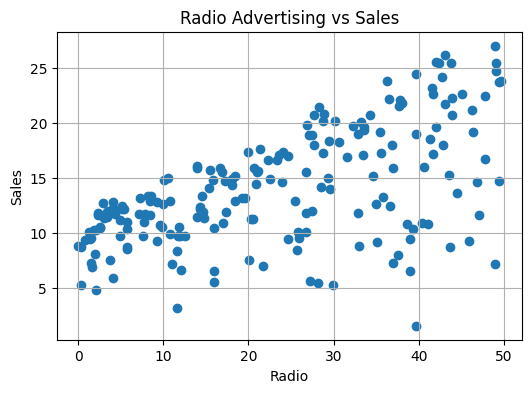

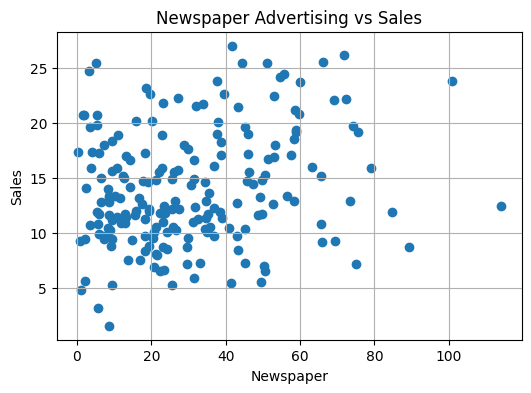


========== MODEL PERFORMANCE ==========
Mean Absolute Error : 1.4607567168117603
Mean Squared Error  : 3.1740973539761033
R2 Score            : 0.899438024100912

First 10 Predictions:
   Actual Sales  Predicted Sales
0          16.9        16.408024
1          22.4        20.889882
2          21.4        21.553843
3           7.3        10.608503
4          24.7        22.112373
5          12.6        13.105592
6          22.3        21.057192
7           8.4         7.461010
8          11.5        13.606346
9          14.9        15.155070


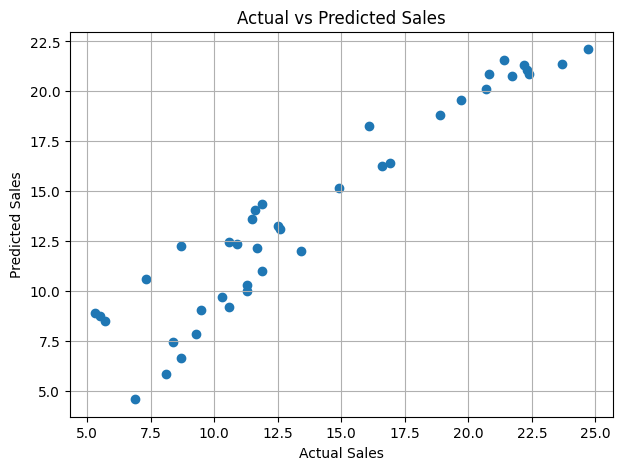


Prediction Example
Enter TV Advertising Budget: 10000
Enter Radio Advertising Budget: 10000
Enter Newspaper Advertising Budget: 7997

Predicted Sales = 2364.31

Project Completed Successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================
# CODEALPHA TASK 4 - SALES PREDICTION USING PYTHON
# ============================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================
# Upload Dataset
# ============================================

print("Upload Advertising.csv")
uploaded = files.upload()

# Load Dataset
df = pd.read_csv("Advertising.csv")

# ============================================
# Display Dataset
# ============================================

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# ============================================
# Remove Unnecessary Column (if present)
# ============================================

if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

print("\nColumns:")
print(df.columns)

# ============================================
# Data Visualization
# ============================================

plt.figure(figsize=(6,4))
plt.scatter(df["TV"], df["Sales"])
plt.title("TV Advertising vs Sales")
plt.xlabel("TV")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df["Radio"], df["Sales"])
plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df["Newspaper"], df["Sales"])
plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# ============================================
# Prepare Features and Target
# ============================================

X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

# ============================================
# Split Dataset
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================
# Train Linear Regression Model
# ============================================

model = LinearRegression()
model.fit(X_train, y_train)

# ============================================
# Predictions
# ============================================

y_pred = model.predict(X_test)

# ============================================
# Model Evaluation
# ============================================

print("\n========== MODEL PERFORMANCE ==========")

print("Mean Absolute Error :", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error  :", mean_squared_error(y_test, y_pred))
print("R2 Score            :", r2_score(y_test, y_pred))

# ============================================
# Actual vs Predicted
# ============================================

result = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

print("\nFirst 10 Predictions:")
print(result.head(10))

# ============================================
# Plot Actual vs Predicted
# ============================================

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.grid(True)
plt.show()

# ============================================
# Predict New Advertisement Budget
# ============================================

print("\nPrediction Example")

tv = float(input("Enter TV Advertising Budget: "))
radio = float(input("Enter Radio Advertising Budget: "))
newspaper = float(input("Enter Newspaper Advertising Budget: "))

prediction = model.predict([[tv, radio, newspaper]])

print("\nPredicted Sales =", round(prediction[0],2))

print("\nProject Completed Successfully!")